## MLP vs FNO

In [2]:
# Cell 1: imports

from functools import partial
import importlib

import matplotlib.pyplot as plt
import torch

import vt_all_solvers_wrapper as vt
import dataset
import utils

importlib.reload(vt)
importlib.reload(dataset)
importlib.reload(utils)

from base_range_library import range_library
from dataset import StreamingGeometryDatasetConfig, make_streaming_dataloader
from utils import (
    DEFAULT_VALIDATION_METRICS,
    TrainConfig,
    fit,
    make_optimizer,
    mse_loss,
    plot_history,
)
from losses import UniversalTransferFunctionLoss
from models.mlp import ProfileMLP, webster_mlp_batch_to_xy
from models.fno import TransferFunctionFNO, webster_fno_batch_to_xy


In [3]:
# Cell 2: общие параметры

device = "cuda" if torch.cuda.is_available() else "cpu"

batch_size = 32
sections = 100
n_profile_points = 128
n_frequencies = 256

steps_per_epoch = 10
val_steps = 10
epochs = 20

mlp_checkpoint_name = "mlp_db"
fno_checkpoint_name = "fno_db"

loss_name = "transfer_db"  # "mse" or "transfer_db"
transfer_loss_db_kwargs = {
    "output_type": "db",
    "db_weight": 1.0,
    "magnitude_weight": 0.1,
    "db_derivative_weight": 0.02,
    "peak_weight": 0.0,
    "complex_weight": 0.0,
    "complex_derivative_weight": 0.0,
    "phase_weight": 0.0,
    "db_error_scale": 10.0,
    "db_derivative_scale": 0.01,
    "peak_temperature_db": 3.0,
    "phase_dynamic_range_db": 40.0,
    "min_db": -100.0,
    "eps": 1e-8,
}

solver_config = vt.SolverConfig(
    solver="cone",
    sections=sections,
    points=n_frequencies,
    f_min_hz=50.0,
    f_max_hz=5000.0,
    grid="linear",
)

train_config = StreamingGeometryDatasetConfig(
    geometry_kind="random",
    solver_config=solver_config,
    target_mode="db",
    seed=1,
)

val_config = StreamingGeometryDatasetConfig(
    geometry_kind="random",
    solver_config=solver_config,
    target_mode="db",
    seed=100_000,
    max_samples=batch_size * val_steps,
)


In [4]:
# Cell 3: dataloaders

train_loader = make_streaming_dataloader(
    train_config,
    range_library,
    batch_size=batch_size,
    num_workers=0,
)

val_loader = make_streaming_dataloader(
    val_config,
    range_library,
    batch_size=batch_size,
    num_workers=0,
)

In [5]:
# Cell 4: MLP/FNO batch adapters

mlp_batch_to_xy = partial(
    webster_mlp_batch_to_xy,
    n_points=n_profile_points,
    log_area=True,
    include_x=True,
)

fno_batch_to_xy = partial(
    webster_fno_batch_to_xy,
    n_points=n_profile_points,
    log_area=True,
)


In [6]:
# Cell 4.5: validation metrics

validation_metrics = list(DEFAULT_VALIDATION_METRICS.keys())
validation_metrics


['mae',
 'rmse',
 'rel_l2',
 'magnitude_mae_db',
 'magnitude_rmse_db',
 'magnitude_max_abs_error_db',
 'relative_derivative_l2',
 'dominant_peak_frequency_mae_hz',
 'dominant_peak_level_mae_db',
 'dominant_notch_frequency_mae_hz',
 'dominant_notch_level_mae_db',
 'relative_complex_l2_percent',
 'phase_mae_degrees']

In [7]:
# Cell 4.6: selectable training loss

transfer_loss_db = UniversalTransferFunctionLoss(**transfer_loss_db_kwargs)

loss_registry = {
    "mse": mse_loss,
    "transfer_db": transfer_loss_db,
}

criterion = loss_registry[loss_name]
criterion


UniversalTransferFunctionLoss()

### MLP

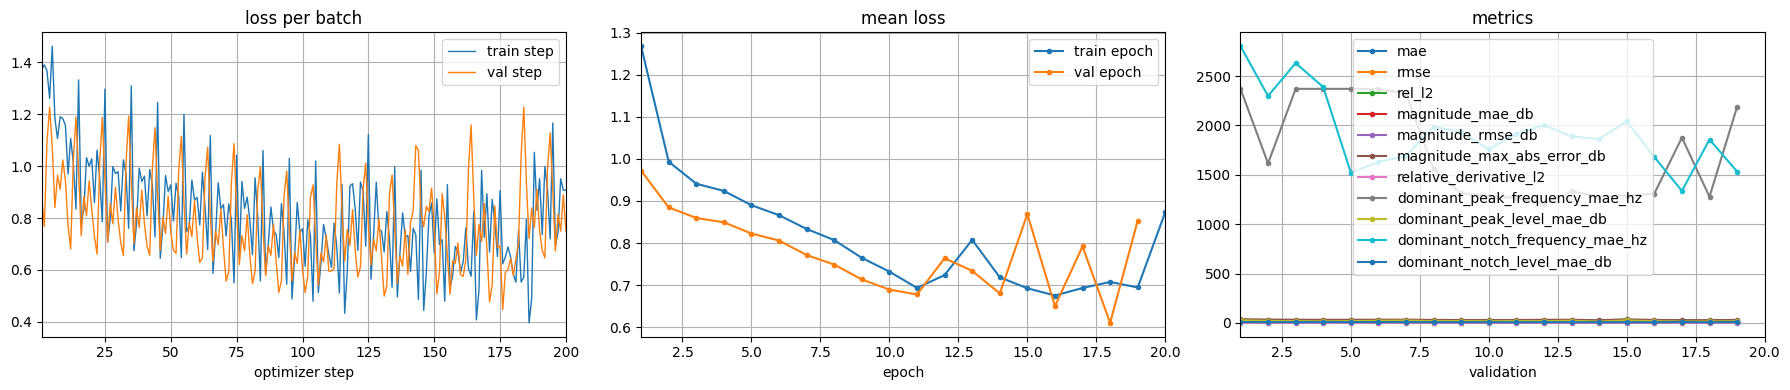

epoch 020/20 | train=0.87371 | val=0.822146 | lr=0.001


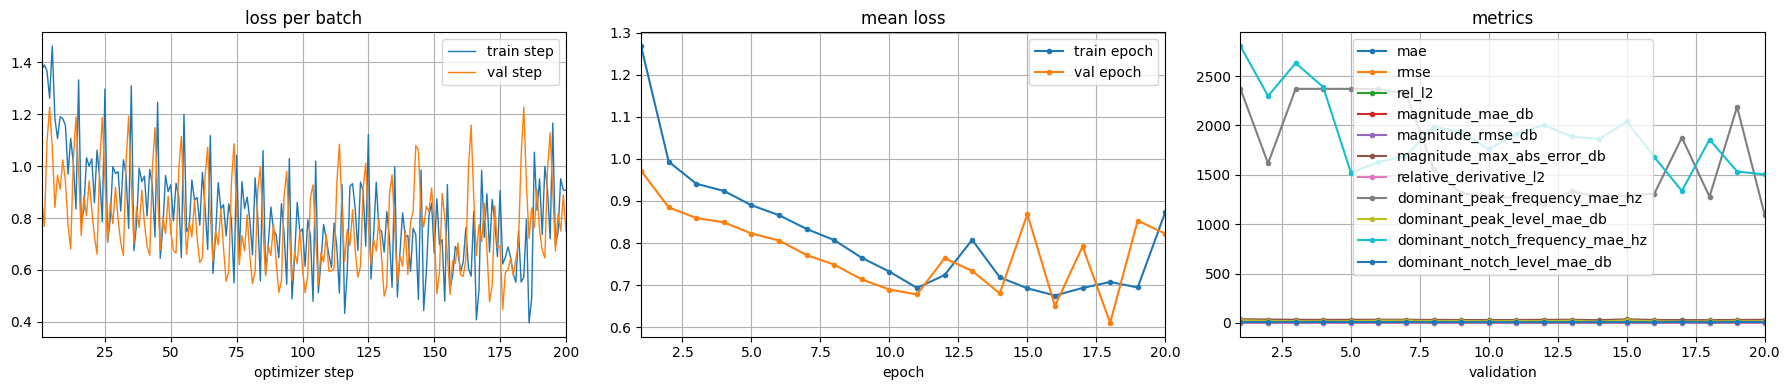

In [8]:
# Cell 5: train MLP

mlp = ProfileMLP(
    n_profile_points=n_profile_points,
    in_channels=2,  # log(area), x
    n_frequencies=n_frequencies,
    hidden_dim=512,
    depth=4,
    dropout=0.05,
    out_channels=1,
).to(device)

mlp_optimizer = make_optimizer(
    mlp,
    lr=1e-3,
    weight_decay=1e-4,
)

mlp_history = fit(
    mlp,
    mlp_optimizer,
    train_loader,
    val_loader,
    criterion=criterion,
    batch_to_xy=mlp_batch_to_xy,
    config=TrainConfig(
        epochs=epochs,
        steps_per_epoch=steps_per_epoch,
        val_steps=val_steps,
        device=device,
        show_progress=False,
        live_plot_every_steps=50,
        grad_clip_norm=None,
        checkpoint_name=mlp_checkpoint_name,
        save_every_steps=None,
        validation_metrics=validation_metrics,
    ),
)

plot_history(mlp_history)


### FNO

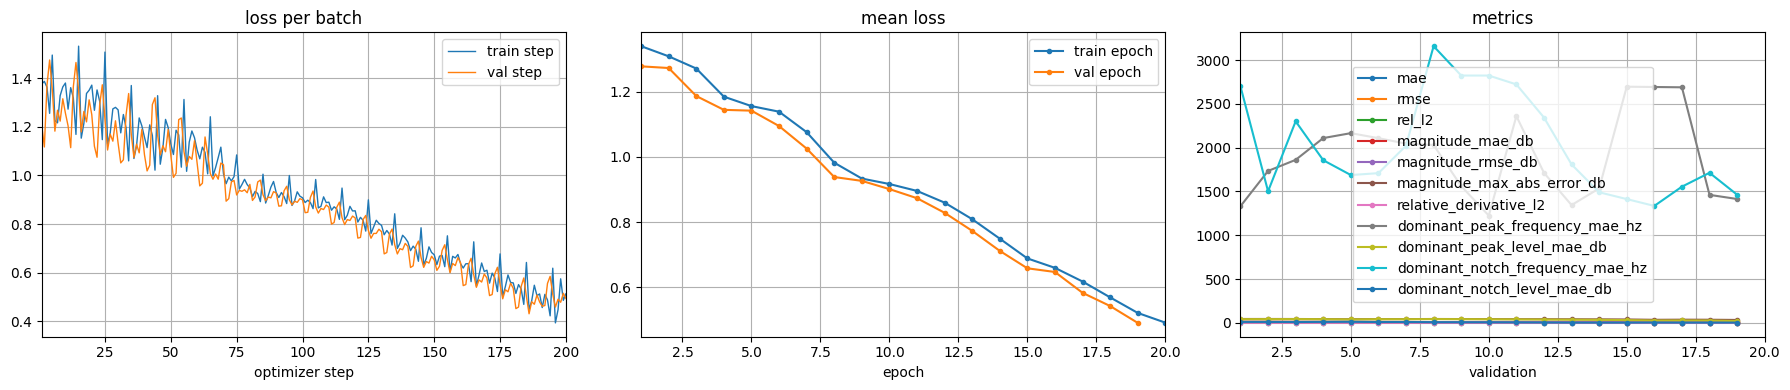

epoch 020/20 | train=0.491826 | val=0.502237 | lr=0.0005


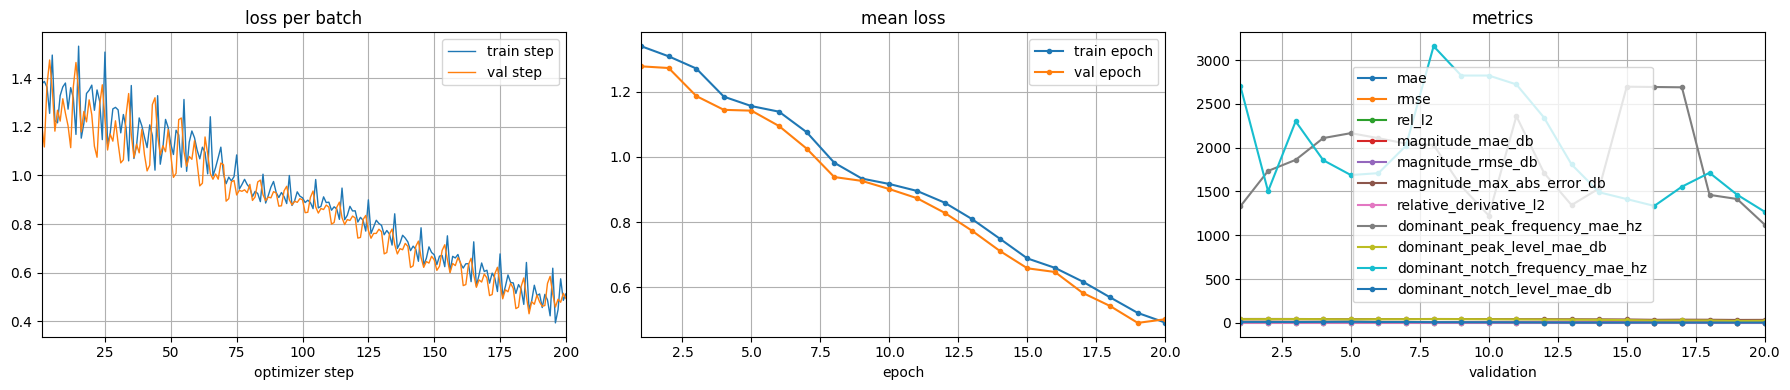

In [9]:
# Cell 6: train FNO

fno = TransferFunctionFNO(
    n_modes=32,
    hidden_channels=96,
    latent_dim=256,
    pooling_bins=16,
    frequency_bands=16,
    out_channels=1,  # dB: output shape [B, Nf]
).to(device)

fno_optimizer = make_optimizer(
    fno,
    lr=5e-4,
    weight_decay=1e-4,
)

fno_history = fit(
    fno,
    fno_optimizer,
    train_loader,
    val_loader,
    criterion=criterion,
    batch_to_xy=fno_batch_to_xy,
    config=TrainConfig(
        epochs=epochs,
        steps_per_epoch=steps_per_epoch,
        val_steps=val_steps,
        device=device,
        show_progress=False,
        live_plot_every_steps=50,
        grad_clip_norm=None,
        checkpoint_name=fno_checkpoint_name,
        save_every_steps=None,
        validation_metrics=validation_metrics,
    ),
)

plot_history(fno_history)


### Сравнение

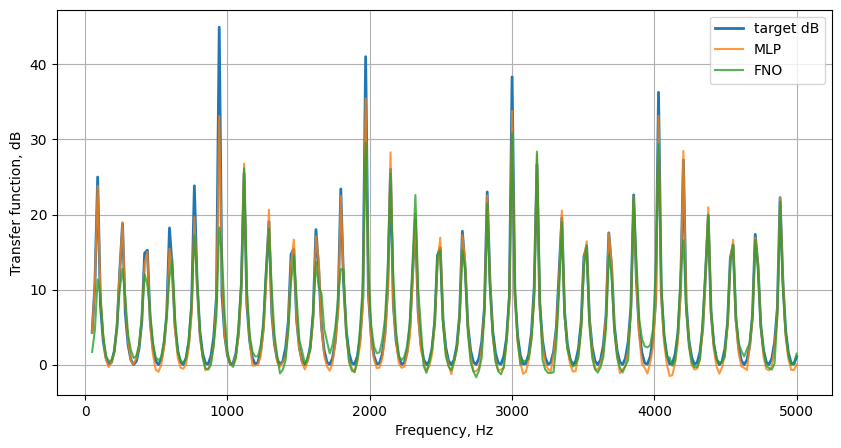

In [10]:
# Cell 7: сравнение на одном validation batch

val_iter = iter(val_loader)
batch = next(val_iter)
sample_idx = 0

mlp.eval()
fno.eval()

with torch.no_grad():
    x_mlp, y = mlp_batch_to_xy(batch, torch.device(device))
    pred_mlp = mlp(x_mlp)

    x_fno, _ = fno_batch_to_xy(batch, torch.device(device))
    pred_fno = fno(*x_fno)

freq = batch["frequencies_hz"][sample_idx].cpu()
target = y[sample_idx].cpu()
mlp_pred = pred_mlp[sample_idx].cpu()
fno_pred = pred_fno[sample_idx].cpu()

plt.figure(figsize=(10, 5))
plt.plot(freq, target, label="target dB", linewidth=2)
plt.plot(freq, mlp_pred, label="MLP", alpha=0.8)
plt.plot(freq, fno_pred, label="FNO", alpha=0.8)
plt.xlabel("Frequency, Hz")
plt.ylabel("Transfer function, dB")
plt.grid(True)
plt.legend()
plt.show()


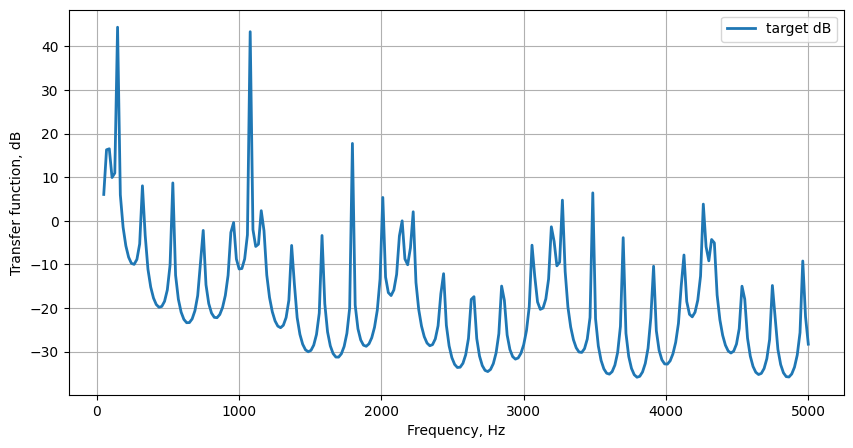

In [11]:
# Cell 8: sanity-check target only

batch = next(iter(val_loader))
sample_idx = 2

with torch.no_grad():
    _, y = mlp_batch_to_xy(batch, torch.device(device))

freq = batch["frequencies_hz"][sample_idx].cpu()
target = y[sample_idx].cpu()

plt.figure(figsize=(10, 5))
plt.plot(freq, target, label="target dB", linewidth=2)
plt.xlabel("Frequency, Hz")
plt.ylabel("Transfer function, dB")
plt.grid(True)
plt.legend()
plt.show()


## 

available keys: dict_keys(['target', 'frequencies_hz', 'geometry', 'meta'])
target batch shape: torch.Size([4, 256, 2])
frequencies batch shape: torch.Size([4, 256])
single sample target shape: (256, 2)


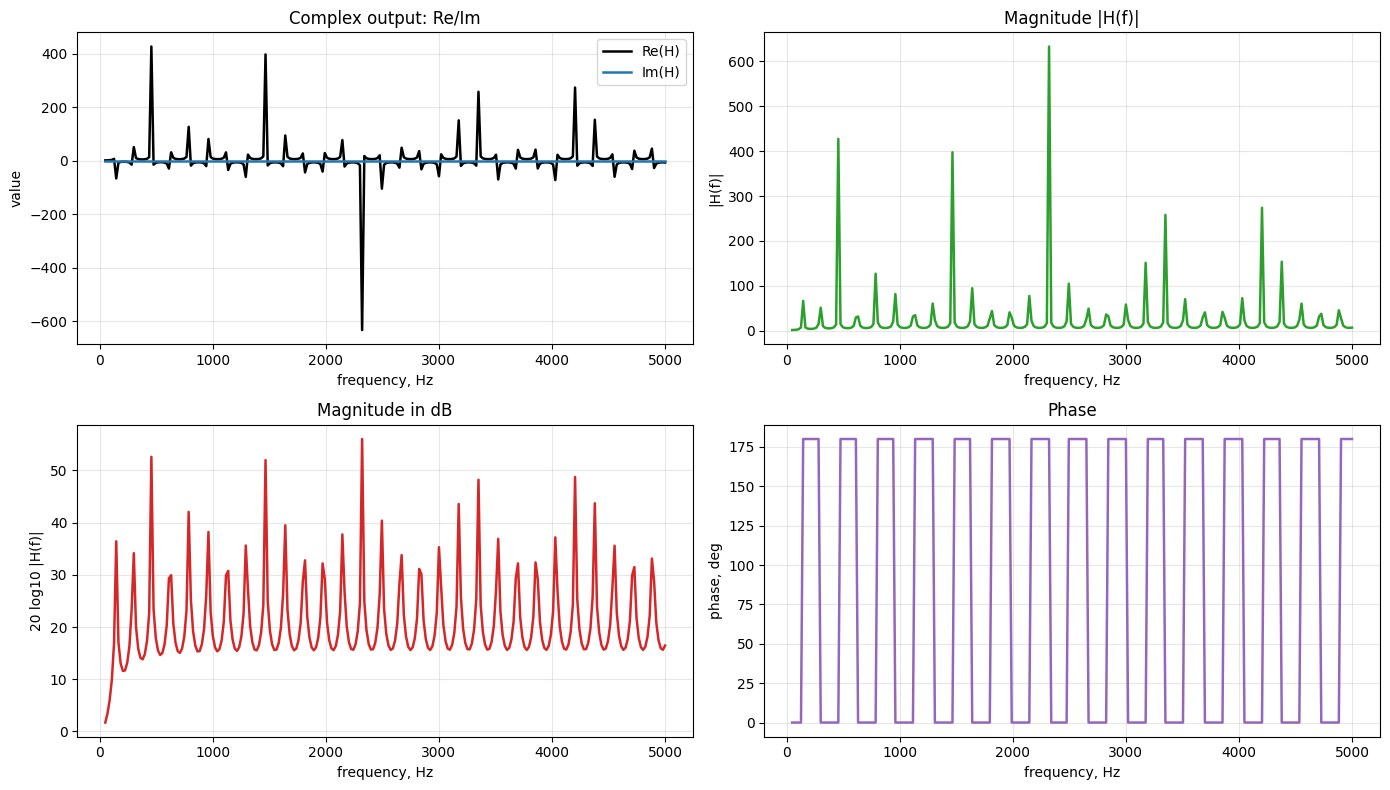

In [12]:
import importlib
import numpy as np
import matplotlib.pyplot as plt
import torch

import vt_all_solvers_wrapper as vt
import dataset
import utils

importlib.reload(vt)
importlib.reload(dataset)
importlib.reload(utils)

from base_range_library import range_library
from dataset import StreamingGeometryDatasetConfig, make_streaming_dataloader

device = "cuda" if torch.cuda.is_available() else "cpu"

batch_size = 4
sections = 100
n_frequencies = 256

solver_config = vt.SolverConfig(
    solver="cone",
    sections=sections,
    points=n_frequencies,
    f_min_hz=50.0,
    f_max_hz=5000.0,
    grid="linear",
    beta_loss_np_per_m=0.0,
)

complex_config = StreamingGeometryDatasetConfig(
    geometry_kind="random",
    solver_config=solver_config,
    target_mode="realimag",
    seed=1,
    max_samples=batch_size,
)

complex_loader = make_streaming_dataloader(
    complex_config,
    range_library,
    batch_size=batch_size,
    num_workers=0,
)

batch = next(iter(complex_loader))

print("available keys:", batch.keys())
print("target batch shape:", batch["target"].shape)
print("frequencies batch shape:", batch["frequencies_hz"].shape)

target = batch["target"][0].detach().cpu().numpy()
freq = batch["frequencies_hz"][0].detach().cpu().numpy()

print("single sample target shape:", target.shape)

re = target[:, 0]
im = target[:, 1]
H = re + 1j * im

magnitude = np.abs(H)
magnitude_db = 20.0 * np.log10(np.maximum(magnitude, 1e-12))
phase_rad = np.angle(H)
phase_deg = np.degrees(phase_rad)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].plot(freq, re, linewidth=1.8, color="black", label="Re(H)")
axes[0, 0].plot(freq, im, linewidth=1.8, color="tab:blue", label="Im(H)")
axes[0, 0].set_title("Complex output: Re/Im")
axes[0, 0].set_xlabel("frequency, Hz")
axes[0, 0].set_ylabel("value")
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

axes[0, 1].plot(freq, magnitude, linewidth=1.8, color="tab:green")
axes[0, 1].set_title("Magnitude |H(f)|")
axes[0, 1].set_xlabel("frequency, Hz")
axes[0, 1].set_ylabel("|H(f)|")
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(freq, magnitude_db, linewidth=1.8, color="tab:red")
axes[1, 0].set_title("Magnitude in dB")
axes[1, 0].set_xlabel("frequency, Hz")
axes[1, 0].set_ylabel("20 log10 |H(f)|")
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(freq, phase_deg, linewidth=1.8, color="tab:purple")
axes[1, 1].set_title("Phase")
axes[1, 1].set_xlabel("frequency, Hz")
axes[1, 1].set_ylabel("phase, deg")
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()